In [4]:
#!pip install -U pyspark==4.0.1


In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("TestSparkLocal") \
    .config("spark.driver.memory", "6g") \
    .getOrCreate()

print("✅ Spark version:", spark.version)


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
25/11/25 15:00:50 WARN Utils: Your hostname, MacBook-Air-di-Giulia-2.local, resolves to a loopback address: 127.0.0.1; using 192.168.225.186 instead (on interface en0)
25/11/25 15:00:50 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/11/25 15:00:51 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


✅ Spark version: 4.0.1


In [6]:
#!pip install -q kaggle
#!kaggle datasets list -s "us-accidents"
#!kaggle datasets download -d sobhanmoosavi/us-accidents -p ./data --unzip


In [7]:
#import os
#os.makedirs("raw", exist_ok=True)

#!kaggle datasets download -d sobhanmoosavi/us-accidents -p raw
#!unzip -n raw/us-accidents.zip -d raw


In [3]:
csv_path = "../raw/US_Accidents_March23.csv"
df = spark.read.option("header", True).option("inferSchema", True).csv(csv_path)

print("✅ Righe:", df.count())
print("✅ Colonne:", len(df.columns))
df.show(5, truncate=False)


25/11/25 15:01:27 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


✅ Righe: 7728394
✅ Colonne: 46
+---+-------+--------+-------------------+-------------------+-----------------+------------------+-------+-------+------------+-------------------------------------------------------------------------------------+-------------------------+------------+----------+-----+----------+-------+----------+------------+-------------------+--------------+-------------+-----------+------------+--------------+--------------+---------------+-----------------+-----------------+-------+-----+--------+--------+--------+-------+-------+----------+-------+-----+---------------+--------------+------------+--------------+--------------+-----------------+---------------------+
|ID |Source |Severity|Start_Time         |End_Time           |Start_Lat        |Start_Lng         |End_Lat|End_Lng|Distance(mi)|Description                                                                          |Street                   |City        |County    |State|Zipcode   |Country|Timezone  |Air

In [9]:
df.limit(10).toPandas()


,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,NaN,NaN,0.01,...,False,False,False,False,True,False,Night,Night,Day,Day
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Day,Day,Day
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,NaN,NaN,0.01,...,False,False,False,False,True,False,Day,Day,Day,Day
5,A-6,Source2,3,2016-02-08 07:44:26,2016-02-08 08:14:26,40.100590,-82.925194,NaN,NaN,0.01,...,False,False,False,False,False,False,Day,Day,Day,Day
6,A-7,Source2,2,2016-02-08 07:59:35,2016-02-08 08:29:35,39.758274,-84.230507,NaN,NaN,0.00,...,False,False,False,False,False,False,Day,Day,Day,Day
7,A-8,Source2,3,2016-02-08 07:59:58,2016-02-08 08:29:58,39.770382,-84.194901,NaN,NaN,0.01,...,False,False,False,False,False,False,Day,Day,Day,Day
8,A-9,Source2,2,2016-02-08 08:00:40,2016-02-08 08:30:40,39.778061,-84.172005,NaN,NaN,0.00,...,False,False,False,False,False,False,Day,Day,Day,Day
9,A-10,Source2,3,2016-02-08 08:10:04,2016-02-08 08:40:04,40.100590,-82.925194,NaN,NaN,0.01,...,False,False,False,False,False,False,Day,Day,Day,Day


In [5]:
df.printSchema()


root
 |-- ID: string (nullable = true)
 |-- Source: string (nullable = true)
 |-- Severity: integer (nullable = true)
 |-- Start_Time: timestamp (nullable = true)
 |-- End_Time: timestamp (nullable = true)
 |-- Start_Lat: double (nullable = true)
 |-- Start_Lng: double (nullable = true)
 |-- End_Lat: double (nullable = true)
 |-- End_Lng: double (nullable = true)
 |-- Distance(mi): double (nullable = true)
 |-- Description: string (nullable = true)
 |-- Street: string (nullable = true)
 |-- City: string (nullable = true)
 |-- County: string (nullable = true)
 |-- State: string (nullable = true)
 |-- Zipcode: string (nullable = true)
 |-- Country: string (nullable = true)
 |-- Timezone: string (nullable = true)
 |-- Airport_Code: string (nullable = true)
 |-- Weather_Timestamp: timestamp (nullable = true)
 |-- Temperature(F): double (nullable = true)
 |-- Wind_Chill(F): double (nullable = true)
 |-- Humidity(%): double (nullable = true)
 |-- Pressure(in): double (nullable = true)
 |-- V

# statistiche descrittive

In [12]:
# Calcola le statistiche descrittive con PySpark
desc_spark = df.describe()

# Converte in Pandas per una visualizzazione leggibile
desc_pd = desc_spark.toPandas().set_index("summary")

# Mostra la tabella formattata
desc_pd


,ID,Source,Severity,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Description,Street,...,Pressure(in),Visibility(mi),Wind_Direction,Wind_Speed(mph),Precipitation(in),Weather_Condition,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
summary,,,,,,,,,,,,,,,,,,,,,
count,7728394,7728394,7728394,7728394,7728394,4325632,4325632,7728394,7728389,7717525,...,7587715,7551296,7553188,7157161,5524808,7554935,7705148,7705148,7705148,7705148
mean,None,None,2.212384487643875,36.20119454946952,-94.70254538794683,36.26182889161967,-95.72557026006884,0.5618422831523706,1096.6666666666667,59.833333333333336,...,29.538985607656194,9.090376447963413,None,7.685489595665597,0.008407209807109432,None,None,None,None,None
stddev,None,None,0.4875313339360398,5.076079113874013,17.39175625334916,5.272904539384689,18.10792763629359,1.7768106031970923,171.95146900305244,113.85139982862685,...,1.00618980914562,2.68831592141714,None,5.424983437161068,0.11022464885795538,None,None,None,None,None
min,A-1,Source1,1,24.5548,-124.623833,24.566013,-124.545748,0.0,1039 GOLDEN BEAR - BOT,1 1/2 Ave,...,0.0,0.0,CALM,0.0,0.0,Blowing Dust,Day,Day,Day,Day
max,A-999999,Source3,4,49.002201,-67.113167,49.075,-67.10924200000001,441.75,VEHICLE CRASH I77 SB NEAR LAKEVIEW ROAD THAT ...,william Carey Dr,...,58.63,140.0,West,1087.0,36.47,Wintry Mix / Windy,Night,Night,Night,Night


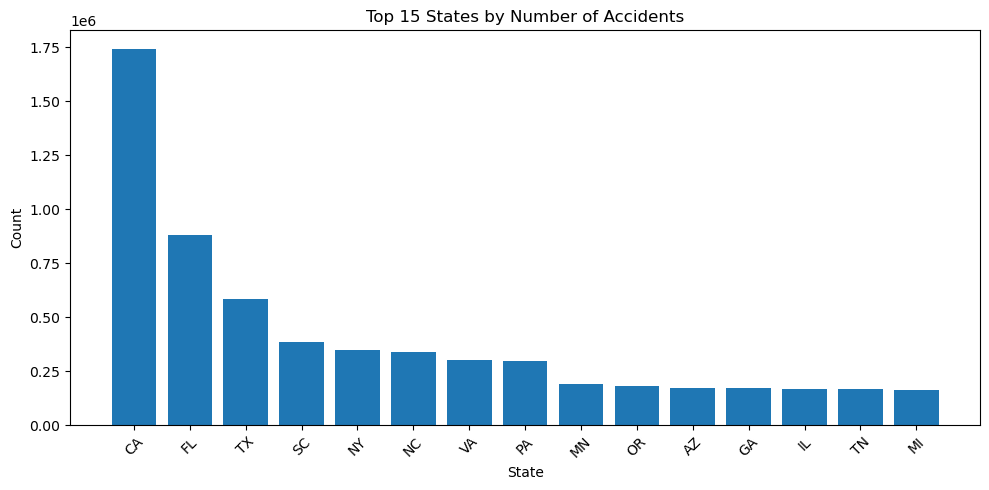

In [13]:
import matplotlib.pyplot as plt

df_state = df.groupBy("State").count().orderBy("count", ascending=False)
pdf_state = df_state.limit(15).toPandas()

plt.figure(figsize=(10,5))
plt.bar(pdf_state["State"], pdf_state["count"])
plt.title("Top 15 States by Number of Accidents")
plt.xlabel("State")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## CORRELAZIONE VARIABILI

In [14]:
import pandas as pd

# Seleziona solo colonne numeriche
num_cols = [c for c, t in df.dtypes if t in ("double", "int")]

# Campiona per non sovraccaricare la RAM (5% dei dati è sufficiente)
pdf = df.select(num_cols).sample(fraction=0.05, seed=42).toPandas()

# Calcola la correlation matrix
corr = pdf.corr(method='pearson')

# Mostra la mappa di correlazione con valori numerici
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
print("🔹 Correlation matrix (Pearson):")
print(corr.round(2))

🔹 Correlation matrix (Pearson):
                   Severity  Start_Lat  Start_Lng  End_Lat  End_Lng  \
Severity               1.00       0.07       0.05     0.08     0.10   
Start_Lat              0.07       1.00      -0.07     1.00    -0.12   
Start_Lng              0.05      -0.07       1.00    -0.12     1.00   
End_Lat                0.08       1.00      -0.12     1.00    -0.12   
End_Lng                0.10      -0.12       1.00    -0.12     1.00   
Distance(mi)           0.04       0.06       0.01     0.07     0.00   
Temperature(F)        -0.02      -0.44      -0.01    -0.47     0.03   
Wind_Chill(F)         -0.07      -0.48      -0.03    -0.49     0.01   
Humidity(%)            0.02       0.02       0.18     0.03     0.17   
Pressure(in)           0.04      -0.20       0.19    -0.24     0.22   
Visibility(mi)        -0.00      -0.09      -0.02    -0.12     0.00   
Wind_Speed(mph)        0.04       0.03       0.08     0.01     0.09   
Precipitation(in)      0.02       0.00       

## MISSING VALUES

In [16]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, isnan, trim

# Conta i missing per ciascuna colonna in base al tipo
for c, t in df.dtypes:
    if t in ["double", "float", "int", "bigint", "decimal"]:
        # colonne numeriche → controlla anche isnan()
        missing_df = df.filter(col(c).isNull() | isnan(col(c)))
    else:
        # stringhe, timestamp, boolean, ecc. → controlla solo null o stringa vuota
        missing_df = df.filter(col(c).isNull() | (trim(col(c)) == ""))
    n = missing_df.count()
    print(f"{c:25} → {n} missing values")


ID                        → 0 missing values


Source                    → 0 missing values


Severity                  → 0 missing values


Start_Time                → 0 missing values


End_Time                  → 0 missing values


...

Turning_Loop              → 0 missing values


Sunrise_Sunset            → 23246 missing values


Civil_Twilight            → 23246 missing values


Nautical_Twilight         → 23246 missing values


Astronomical_Twilight     → 23246 missing values


## QUANTI NULL CI SONO PER COMBINAZIONE TRA WC, TEMP, PREC, VISIBIL, HUM

In [20]:
df.groupBy(
    F.when(F.col("Temperature(F)").isNull(), "T").otherwise("_").alias("Temp_null"),
    F.when(F.col("Humidity(%)").isNull(), "H").otherwise("_").alias("Hum_null"),
    F.when(F.col("Precipitation(in)").isNull(), "P").otherwise("_").alias("Prec_null"),
    F.when(F.col("Visibility(mi)").isNull(), "V").otherwise("_").alias("Vis_null"),
    F.when(F.col("Weather_Condition").isNull() | (F.trim(F.col("Weather_Condition")) == ""), "W").otherwise("_").alias("Wea_null")
).agg(F.count("*").alias("count")) \
 .orderBy(F.desc("count")) \
 .show(30, truncate=False)


+---------+--------+---------+--------+--------+-------+
|Temp_null|Hum_null|Prec_null|Vis_null|Wea_null|count  |
+---------+--------+---------+--------+--------+-------+
|_        |_       |_        |_       |_       |5455470|
|_        |_       |P        |_       |_       |2043014|
|T        |H       |P        |V       |W       |128190 |
|T        |H       |_        |_       |_       |17444  |
|_        |_       |_        |V       |_       |14322  |
|_        |_       |_        |V       |W       |10167  |
|_        |_       |P        |V       |W       |9932   |
|_        |_       |_        |_       |W       |9784   |
|T        |H       |P        |_       |_       |8357   |
|T        |H       |_        |V       |W       |8128   |
|_        |H       |_        |_       |_       |8127   |
|_        |_       |P        |_       |W       |6601   |
|_        |_       |P        |V       |_       |4960   |
|_        |H       |P        |_       |_       |1913   |
|T        |H       |_        |V

# CANCELLAZIONE DI QUELLE A CUI MANCANO TUTTE E 5 

In [22]:
from pyspark.sql import functions as F

# 1️⃣ Conta quanti record hanno TUTTE le variabili meteo nulle
missing_all = df.filter(
    F.col("Weather_Condition").isNull() &
    F.col("Precipitation(in)").isNull() &
    F.col("Temperature(F)").isNull() &
    F.col("Humidity(%)").isNull() &
    F.col("Visibility(mi)").isNull()
).count()

print(f"Record completamente privi di dati meteo: {missing_all}")

# 2️⃣ Elimina solo quei record
df = df.filter(~(
    F.col("Weather_Condition").isNull() &
    F.col("Precipitation(in)").isNull() &
    F.col("Temperature(F)").isNull() &
    F.col("Humidity(%)").isNull() &
    F.col("Visibility(mi)").isNull()
))

# 3️⃣ Verifica quante righe sono rimaste
print(f"Righe rimanenti dopo la rimozione: {df.count()}")


Record completamente privi di dati meteo: 128190


Righe rimanenti dopo la rimozione: 7600204


## rimozione end_lat e end_lng

In [23]:
from pyspark.sql.functions import col, isnan

# Calcola percentuale di missing per End_Lat e End_Lng
total = df.count()

for c in ["End_Lat", "End_Lng"]:
    miss = df.filter(col(c).isNull() | isnan(col(c))).count()
    perc = round((miss / total) * 100, 2)
    print(f"{c}: {perc}% missing")
    if perc > 40:
        df = df.drop(c)
        print(f" Rimossa {c} (troppe celle vuote)")

print("Colonne finali:", len(df.columns))

# Salva la versione aggiornata del dataset
df.write.mode("overwrite").parquet("data/us_accidents_step1")


End_Lat: 44.18% missing
➡️ Rimossa End_Lat (troppe celle vuote)


End_Lng: 44.18% missing
➡️ Rimossa End_Lng (troppe celle vuote)
✅ Colonne finali: 44


## Check colonne

In [24]:
df.printSchema()
print("Righe:", df.count())
print("Colonne:", len(df.columns))


root
 |-- ID: string (nullable = true)
 |-- Source: string (nullable = true)
 |-- Severity: integer (nullable = true)
 |-- Start_Time: timestamp (nullable = true)
 |-- End_Time: timestamp (nullable = true)
 |-- Start_Lat: double (nullable = true)
 |-- Start_Lng: double (nullable = true)
 |-- Distance(mi): double (nullable = true)
 |-- Description: string (nullable = true)
 |-- Street: string (nullable = true)
 |-- City: string (nullable = true)
 |-- County: string (nullable = true)
 |-- State: string (nullable = true)
 |-- Zipcode: string (nullable = true)
 |-- Country: string (nullable = true)
 |-- Timezone: string (nullable = true)
 |-- Airport_Code: string (nullable = true)
 |-- Weather_Timestamp: timestamp (nullable = true)
 |-- Temperature(F): double (nullable = true)
 |-- Wind_Chill(F): double (nullable = true)
 |-- Humidity(%): double (nullable = true)
 |-- Pressure(in): double (nullable = true)
 |-- Visibility(mi): double (nullable = true)
 |-- Wind_Direction: string (nullable 

Righe: 7600204
Colonne: 44


## divisione di start time in anno mese giorno ora e giorno settimana 

In [26]:
from pyspark.sql.functions import year, month, dayofmonth, dayofweek, hour, to_timestamp, col

# 1️⃣ Converti direttamente Start_Time in timestamp (senza creare Start_ts)
df = df.withColumn("Start_Time", to_timestamp(col("Start_Time")))

# 2️⃣ Estrai le componenti temporali
df = df.withColumn("Year", year("Start_Time")) \
       .withColumn("Month", month("Start_Time")) \
       .withColumn("Day", dayofmonth("Start_Time")) \
       .withColumn("Weekday", dayofweek("Start_Time")) \
       .withColumn("Hour", hour("Start_Time"))

# 3️⃣ Salva in Parquet
df.write.mode("overwrite").parquet("data/us_accidents_step1")


## RIMOZIONE WIND CHILL

In [28]:
df = df.drop("Wind_Chill(F)")

In [29]:
df.limit(5).toPandas()

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,Distance(mi),Description,Street,City,County,State,Zipcode,Country,Timezone,Airport_Code,Weather_Timestamp,Temperature(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Direction,Wind_Speed(mph),Precipitation(in),Weather_Condition,Amenity,Bump,Crossing,Give_Way,Junction,No_Exit,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight,Year,Month,Day,Weekday,Hour
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,0.01,Right lane blocked due to accident on I-70 Eas...,I-70 E,Dayton,Montgomery,OH,45424,US,US/Eastern,KFFO,2016-02-08 05:58:00,36.9,91.0,29.68,10.0,Calm,NaN,0.02,Light Rain,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Night,Night,Night,2016,2,8,2,5
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,0.01,Accident on Brice Rd at Tussing Rd. Expect del...,Brice Rd,Reynoldsburg,Franklin,OH,43068-3402,US,US/Eastern,KCMH,2016-02-08 05:51:00,37.9,100.0,29.65,10.0,Calm,NaN,0.00,Light Rain,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Night,Night,Day,2016,2,8,2,6
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,0.01,Accident on OH-32 State Route 32 Westbound at ...,State Route 32,Williamsburg,Clermont,OH,45176,US,US/Eastern,KI69,2016-02-08 06:56:00,36.0,100.0,29.67,10.0,SW,3.5,NaN,Overcast,False,False,False,False,False,False,False,False,False,False,False,True,False,Night,Night,Day,Day,2016,2,8,2,6
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,0.01,Accident on I-75 Southbound at Exits 52 52B US...,I-75 S,Dayton,Montgomery,OH,45417,US,US/Eastern,KDAY,2016-02-08 07:38:00,35.1,96.0,29.64,9.0,SW,4.6,NaN,Mostly Cloudy,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Day,Day,Day,2016,2,8,2,7
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,0.01,Accident on McEwen Rd at OH-725 Miamisburg Cen...,Miamisburg Centerville Rd,Dayton,Montgomery,OH,45459,US,US/Eastern,KMGY,2016-02-08 07:53:00,36.0,89.0,29.65,6.0,SW,3.5,NaN,Mostly Cloudy,False,False,False,False,False,False,False,False,False,False,False,True,False,Day,Day,Day,Day,2016,2,8,2,7


# LE 145 CATEGORIE DI WEATH COND

In [31]:
df.groupBy("Weather_Condition") \
  .count() \
  .orderBy("count", ascending=False) \
  .show(145, truncate=False)


+-----------------------------------+-------+
|Weather_Condition                  |count  |
+-----------------------------------+-------+
|Fair                               |2560802|
|Mostly Cloudy                      |1016195|
|Cloudy                             |817082 |
|Clear                              |808743 |
|Partly Cloudy                      |698972 |
|Overcast                           |382866 |
|Light Rain                         |352957 |
|Scattered Clouds                   |204829 |
|Light Snow                         |128680 |
|Fog                                |99238  |
|Rain                               |84331  |
|Haze                               |76223  |
|NULL                               |45269  |
|Fair / Windy                       |35671  |
|Heavy Rain                         |32309  |
|Light Drizzle                      |22684  |
|Thunder in the Vicinity            |17611  |
|Cloudy / Windy                     |17035  |
|T-Storm                          

# SUDDIVISIONE IN 12 MACROCATEGORIE DI WEATH COND (+ 1 Missing)

In [33]:
from pyspark.sql.functions import when, col

df = df.withColumn("weather_grouped", when(col("Weather_Condition").rlike("(?i)light.*rain"), "Light Rain")
    .when(col("Weather_Condition").rlike("(?i)heavy.*rain"), "Heavy Rain")
    .when(col("Weather_Condition").rlike("(?i)light.*snow"), "Light Snow")
    .when(col("Weather_Condition").rlike("(?i)heavy.*snow"), "Heavy Snow")
    .when(col("Weather_Condition").rlike("(?i)light.*fog|light.*haze"), "Light Fog")
    .when(col("Weather_Condition").rlike("(?i)heavy.*fog|heavy.*haze"), "Heavy Fog")
    .when(col("Weather_Condition").rlike("(?i)thunder|t-storm"), "Thunderstorm")
    .when(col("Weather_Condition").rlike("(?i)clear|fair"), "Clear")
    .when(col("Weather_Condition").rlike("(?i)cloud|overcast"), "Cloudy")
    .when(col("Weather_Condition").rlike("(?i)snow|sleet|ice|hail"), "Snow/Ice")
    .when(col("Weather_Condition").rlike("(?i)fog|haze|mist|smoke"), "Fog/Haze")
    .when(col("Weather_Condition").isNull(), "Missing")
    .otherwise("Other"))



In [34]:
df.groupBy("weather_grouped").count().orderBy("count", ascending=False).show()


+---------------+-------+
|weather_grouped|  count|
+---------------+-------+
|          Clear|3405216|
|         Cloudy|3163750|
|     Light Rain| 383415|
|       Fog/Haze| 201777|
|     Light Snow| 135891|
|          Other| 134172|
|   Thunderstorm|  67517|
|        Missing|  45269|
|     Heavy Rain|  36340|
|       Snow/Ice|  19920|
|     Heavy Snow|   5922|
|      Light Fog|   1015|
+---------------+-------+



# Precipitation(in)

In [36]:
from pyspark.sql.functions import col, isnan, when, count

# mostra il tipo di dato
dtype = [t for (c, t) in df.dtypes if c == "Precipitation(in)"][0]
print(f"Tipo di 'Precipitation(in)': {dtype}")

# conta quanti sono i null o NaN
null_count = df.select(
    count(when(col("Precipitation(in)").isNull() | isnan(col("Precipitation(in)")), 1)).alias("null_count")
).collect()[0]["null_count"]

print(f"Valori null/NaN in 'Precipitation(in)': {null_count}")


Tipo di 'Precipitation(in)': double


Valori null/NaN in 'Precipitation(in)': 2075396


## outliers precipitation

In [38]:
from pyspark.sql.functions import col

df.selectExpr(
    "min(`Precipitation(in)`) as min_prec",
    "max(`Precipitation(in)`) as max_prec"
).show()


+--------+--------+
|min_prec|max_prec|
+--------+--------+
|     0.0|   36.47|
+--------+--------+



## conteggio di valori > 2 pollici (5 cm) 

In [39]:
from pyspark.sql.functions import col

outlier_prec = df.filter(col("Precipitation(in)") > 2).count()
total = df.count()

print(f"Outlier > 2 pollici: {outlier_prec} su {total} righe ({100*outlier_prec/total:.3f}%)")


Outlier > 2 pollici: 650 su 7600204 righe (0.009%)


In [40]:
from pyspark.sql.functions import col

df.filter(col("Precipitation(in)") > 0) \
  .select("Precipitation(in)") \
  .orderBy(col("Precipitation(in)").desc()) \
  .show(30, truncate=False)


+-----------------+
|Precipitation(in)|
+-----------------+
|36.47            |
|25.0             |
|24.0             |
|24.0             |
|24.0             |
|24.0             |
|23.97            |
|10.8             |
|10.4             |
|10.4             |
|10.18            |
|10.16            |
|10.14            |
|10.14            |
|10.13            |
|10.13            |
|10.11            |
|10.11            |
|10.1             |
|10.09            |
|10.09            |
|10.06            |
|10.05            |
|10.05            |
|10.05            |
|10.05            |
|10.04            |
|10.04            |
|10.04            |
|10.04            |
+-----------------+
only showing top 30 rows


In [41]:
from pyspark.sql.functions import col

df.filter(col("Precipitation(in)") >= 5) \
  .select("ID", "weather_condition", "Temperature(F)", "Precipitation(in)") \
  .orderBy(col("Precipitation(in)").desc()) \
  .show(50, truncate=False)


+---------+---------------------+--------------+-----------------+
|ID       |weather_condition    |Temperature(F)|Precipitation(in)|
+---------+---------------------+--------------+-----------------+
|A-597351 |Fair                 |64.0          |36.47            |
|A-1879782|Cloudy               |70.0          |25.0             |
|A-7340730|Fair                 |72.0          |24.0             |
|A-6788881|Cloudy               |50.0          |24.0             |
|A-6494502|Blowing Snow         |2.0           |24.0             |
|A-6891826|Cloudy               |50.0          |24.0             |
|A-769716 |Light Drizzle        |37.0          |23.97            |
|A-2376248|Overcast             |29.5          |10.8             |
|A-6383413|Partly Cloudy / Windy|61.0          |10.4             |
|A-6424385|Partly Cloudy / Windy|61.0          |10.4             |
|A-2641906|Overcast             |73.4          |10.18            |
|A-2641904|Overcast             |73.4          |10.16         

# range più realistici da assegnare ai valori outliers (quelli > 2 pollici)

In [43]:
from pyspark.sql.functions import col, when

df = df.withColumn(
    "Precipitation(in)",
    when(
        (col("Precipitation(in)") > 2) & 
        (col("weather_grouped").isin("Clear", "Cloudy", "Light Fog", "Fog/Haze", "Missing")),
        0.0
    ).when(
        (col("Precipitation(in)") > 2) & 
        (col("weather_grouped").isin("Light Rain", "Light Snow")),
        0.3
    ).when(
        (col("Precipitation(in)") > 2) & 
        (col("weather_grouped").isin("Other", "Snow/Ice")),
        1.0
    ).when(
        (col("Precipitation(in)") > 2) & 
        (col("weather_grouped").isin("Heavy Rain", "Heavy Snow", "Thunderstorm")),
        2.0
    ).otherwise(col("Precipitation(in)"))
)


## Check di wc, temperature, precipitation > 2

In [44]:
from pyspark.sql.functions import col

df.filter(col("Precipitation(in)") >= 2) \
  .select("ID", "weather_condition", "Temperature(F)", "Precipitation(in)") \
  .orderBy(col("ID").desc()) \
  .show(20, truncate=False)


+---------+----------------------------+--------------+-----------------+
|ID       |weather_condition           |Temperature(F)|Precipitation(in)|
+---------+----------------------------+--------------+-----------------+
|A-972308 |Heavy T-Storm               |73.0          |2.0              |
|A-957909 |Heavy T-Storm               |72.0          |2.0              |
|A-915116 |Heavy T-Storm / Windy       |62.0          |2.0              |
|A-893714 |Heavy T-Storm               |73.0          |2.0              |
|A-7666857|Heavy Thunderstorms and Rain|75.2          |2.0              |
|A-7666854|Heavy Thunderstorms and Rain|75.9          |2.0              |
|A-7547998|Heavy Rain                  |75.0          |2.0              |
|A-6805277|Heavy Rain                  |64.0          |2.0              |
|A-6628919|Heavy T-Storm               |70.0          |2.0              |
|A-6265533|T-Storm                     |78.0          |2.0              |
|A-6255571|T-Storm                    

## check valore max per ogni macrocategoria

In [45]:
df.groupBy("weather_grouped") \
  .agg({"Precipitation(in)": "max"}) \
  .orderBy("max(Precipitation(in))", ascending=False) \
  .show(truncate=False)


+---------------+----------------------+
|weather_grouped|max(Precipitation(in))|
+---------------+----------------------+
|Thunderstorm   |2.0                   |
|Heavy Rain     |2.0                   |
|Other          |1.96                  |
|Light Rain     |1.95                  |
|Cloudy         |1.88                  |
|Clear          |1.8                   |
|Missing        |1.45                  |
|Snow/Ice       |1.43                  |
|Fog/Haze       |1.38                  |
|Heavy Snow     |1.04                  |
|Light Snow     |0.93                  |
|Light Fog      |0.24                  |
+---------------+----------------------+



## imputazione dei null di precipitation con la media di weather_grouped

In [46]:
from pyspark.sql.functions import col, when, avg, round, isnan
from pyspark.sql.window import Window

# finestra per gruppo meteorologico
w = Window.partitionBy("weather_grouped")

# imputazione dei soli NaN / null con la media del gruppo
df = df.withColumn(
    "Precipitation(in)",
    when(
        col("Precipitation(in)").isNull() | isnan(col("Precipitation(in)")),
        round(avg("Precipitation(in)").over(w), 3)
    ).otherwise(col("Precipitation(in)"))
)


In [47]:
import pandas as pd
from pyspark.sql.functions import col

# Mostra tutte le colonne senza troncamenti
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

# Visualizza le prime 20 righe ordinate per ID
df.orderBy(col("ID").asc()).limit(20).toPandas()


,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,Distance(mi),Description,Street,City,County,State,Zipcode,Country,Timezone,Airport_Code,Weather_Timestamp,Temperature(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Direction,Wind_Speed(mph),Precipitation(in),Weather_Condition,Amenity,Bump,Crossing,Give_Way,Junction,No_Exit,Railway,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight,Year,Month,Day,Weekday,Hour,weather_grouped
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,0.01,Right lane blocked due to accident on I-70 Eastbound at Exit 41 OH-235 State Route 4.,I-70 E,Dayton,Montgomery,OH,45424,US,US/Eastern,KFFO,2016-02-08 05:58:00,36.9,91.0,29.68,10.0,Calm,NaN,0.020,Light Rain,False,False,False,False,False,False,False,False,False,False,False,False,False,Night,Night,Night,Night,2016,2,8,2,5,Light Rain
1,A-10,Source2,3,2016-02-08 08:10:04,2016-02-08 08:40:04,40.100590,-82.925194,0.01,Right hand shoulder blocked due to accident on I-270 Outerbelt Westbound at Exit 29 OH-3 State St.,Westerville Rd,Westerville,Franklin,OH,43081,US,US/Eastern,KCMH,2016-02-08 08:28:00,37.4,100.0,29.62,3.0,SSW,4.6,0.020,Light Rain,False,False,False,False,False,False,False,False,False,False,False,False,False,Day,Day,Day,Day,2016,2,8,2,8,Light Rain
2,A-100,Source2,2,2016-02-11 08:13:24,2016-02-11 08:43:24,39.749916,-84.139359,0.01,Accident on US-35 Westbound at Smithville Rd. Expect delays.,US-35 E,Dayton,Montgomery,OH,45410,US,US/Eastern,KFFO,2016-02-11 07:58:00,7.5,87.0,30.28,10.0,SSW,4.6,0.002,Scattered Clouds,False,False,False,False,False,False,False,False,False,False,False,False,False,Day,Day,Day,Day,2016,2,11,5,8,Cloudy
3,A-1000,Source2,2,2016-06-23 10:31:12,2016-06-23 11:01:12,38.653061,-121.070541,0.00,Accident on US-50 Westbound near Exits 30 30A 30B Latrobe Rd.,Latrobe Rd,El Dorado Hills,El Dorado,CA,95762,US,US/Pacific,KMHR,2016-06-23 10:46:00,77.0,34.0,30.02,10.0,SW,3.5,0.000,Clear,False,False,False,False,False,False,False,False,False,False,False,False,False,Day,Day,Day,Day,2016,6,23,5,10,Clear
4,A-10000,Source2,3,2017-01-06 16:22:04,2017-01-06 16:51:29,38.574406,-121.577354,0.01,Right hand shoulder blocked due to accident on I-80 Westbound at Exits 81 82 I-80 Bus Capital City Fwy.,I-80 W,West Sacramento,Yolo,CA,95691,US,US/Pacific,KSAC,2017-01-06 15:53:00,46.0,71.0,30.09,10.0,NW,8.1,0.000,Clear,False,False,False,False,False,False,False,False,False,False,False,False,False,Day,Day,Day,Day,2017,1,6,6,16,Clear
5,A-100000,Source2,2,2016-04-05 15:47:30,2016-04-05 16:47:30,33.940449,-117.875900,0.00,Accident on CA-57 Southbound near Exit 11 Brea Canyon Rd.,CA-57 S,Brea,Orange,CA,92821,US,US/Pacific,KFUL,2016-04-05 15:53:00,84.9,25.0,29.95,10.0,SSW,8.1,0.000,Clear,False,False,False,False,False,False,False,False,False,False,False,False,False,Day,Day,Day,Day,2016,4,5,3,15,Clear
6,A-1000000,Source2,2,2021-06-17 07:28:33,2021-06-17 08:43:18,38.663250,-77.549522,0.00,Accident on VA-646 Aden Rd near Hershey Dr.,Aden Rd,Nokesville,Prince William,VA,20181-2818,US,US/Eastern,KHEF,2021-06-17 07:56:00,64.0,52.0,29.84,10.0,NW,8.0,0.000,Fair,False,False,False,False,False,False,False,False,False,False,False,False,False,Day,Day,Day,Day,2021,6,17,5,7,Clear
7,A-1000001,Source2,3,2021-06-17 07:30:24,2021-06-17 09:00:24,38.870338,-77.299889,0.00,Right hand shoulder blocked due to earlier accident on I-66 Westbound near Exit 60 VA-123 Chain Bridge Rd.,I-66 W,Fairfax,Fairfax County,VA,22030,US,US/Eastern,KIAD,2021-06-17 07:52:00,62.0,52.0,29.71,10.0,VAR,6.0,0.000,Fair,False,False,False,False,False,False,False,False,False,False,False,False,False,Day,Day,Day,Day,2021,6,17,5,7,Clear
8,A-1000002,Source2,2,2021-06-17 07:36:20,2021-06-17 08:50:51,39.086720,-77.490891,0.00,Accident on Commonwealth Ter at Leesmill Sq.,Lees Mill Sq,Leesburg,Loudoun,VA,20176-3818,US,US/Eastern,KJYO,2021-06-17 07:52:00,62.0,52.0,29.71,10.0,VAR,6.0,0.000,Fair,False,False,

In [48]:
df.filter(col("Precipitation(in)").isNull()).count()


0

# IMPUTAZIONE TEMPERATURE (prima controllo outliers)

In [50]:
df.selectExpr(
    "min(`Temperature(F)`) as min_temp",
    "max(`Temperature(F)`) as max_temp"
).show()


+--------+--------+
|min_temp|max_temp|
+--------+--------+
|   -89.0|   207.0|
+--------+--------+



In [51]:
df.select("State").distinct().orderBy("State").show(100, truncate=False)


+-----+
|State|
+-----+
|AL   |
|AR   |
|AZ   |
|CA   |
|CO   |
|CT   |
|DC   |
|DE   |
|FL   |
|GA   |
|IA   |
|ID   |
|IL   |
|IN   |
|KS   |
|KY   |
|LA   |
|MA   |
|MD   |
|ME   |
|MI   |
|MN   |
|MO   |
|MS   |
|MT   |
|NC   |
|ND   |
|NE   |
|NH   |
|NJ   |
|NM   |
|NV   |
|NY   |
|OH   |
|OK   |
|OR   |
|PA   |
|RI   |
|SC   |
|SD   |
|TN   |
|TX   |
|UT   |
|VA   |
|VT   |
|WA   |
|WI   |
|WV   |
|WY   |
+-----+



## calcolo outliers e imputazione dei null tramite metodo iqr che mi fa una combinazione tra state e month

In [53]:
from pyspark.sql import functions as F

#Calcolo IQR per ogni combinazione State + Month
iqr_limits = (
    df.groupBy("State", "Month")
      .agg(
          F.percentile_approx("Temperature(F)", 0.25).alias("q1"),
          F.percentile_approx("Temperature(F)", 0.75).alias("q3")
      )
      .withColumn("iqr", F.col("q3") - F.col("q1"))
      # uso margine più largo per garantire 0 outliers
      .withColumn("lower_bound", F.col("q1") - 2 * F.col("iqr"))
      .withColumn("upper_bound", F.col("q3") + 2 * F.col("iqr"))
)

# Join dei limiti e calcolo media locale per eventuali imputazioni
df = df.join(iqr_limits, on=["State", "Month"], how="left")

mean_temp = (
    df.groupBy("State", "Month")
      .agg(F.mean("Temperature(F)").alias("mean_temp"))
)
df = df.join(mean_temp, on=["State", "Month"], how="left")

# Sostituisco:
#     - i null con la media locale
#     - gli outlier con la media locale ± correzione leggera se piove
df = df.withColumn(
    "Temperature(F)",
    F.when(
        F.col("Temperature(F)").isNull(),
        F.when(F.col("Precipitation(in)") > 0, F.col("mean_temp") - 1).otherwise(F.col("mean_temp"))
    ).when(
        (F.col("Temperature(F)") < F.col("lower_bound")) | (F.col("Temperature(F)") > F.col("upper_bound")),
        F.when(F.col("Precipitation(in)") > 0, F.col("mean_temp") - 1).otherwise(F.col("mean_temp"))
    ).otherwise(F.col("Temperature(F)"))
)

# Pulizia finale colonne temporanee
df = df.drop("mean_temp", "q1", "q3", "iqr", "lower_bound", "upper_bound")

# Verifica finale
n_null = df.filter(F.col("Temperature(F)").isNull()).count()
print("Null rimasti in Temperature(F):", n_null)

# Calcolo nuovi limiti per sicurezza e controllo se esistono outlier residui
check_limits = (
    df.groupBy("State", "Month")
      .agg(
          F.percentile_approx("Temperature(F)", 0.25).alias("q1"),
          F.percentile_approx("Temperature(F)", 0.75).alias("q3")
      )
      .withColumn("iqr", F.col("q3") - F.col("q1"))
      .withColumn("lower_bound", F.col("q1") - 2 * F.col("iqr"))
      .withColumn("upper_bound", F.col("q3") + 2 * F.col("iqr"))
)

df = df.join(check_limits, on=["State", "Month"], how="left")

remaining_outliers = df.filter(
    (F.col("Temperature(F)") < F.col("lower_bound")) | (F.col("Temperature(F)") > F.col("upper_bound"))
).count()

print(" Outlier residui in Temperature(F):", remaining_outliers)


Null rimasti in Temperature(F): 0


 Outlier residui in Temperature(F): 4507


## vedo in che mese e stato si trovano gli outliers rimanenenti

In [54]:
from pyspark.sql import functions as F

outlier_groups = (
    df.filter((F.col("Temperature(F)") < F.col("lower_bound")) | (F.col("Temperature(F)") > F.col("upper_bound")))
      .groupBy("State", "Month")
      .agg(F.count("*").alias("n_outliers"))
      .orderBy(F.desc("n_outliers"))
)

outlier_groups.show(50, truncate=False)


+-----+-----+----------+
|State|Month|n_outliers|
+-----+-----+----------+
|FL   |11   |912       |
|CA   |12   |660       |
|FL   |12   |584       |
|CA   |2    |345       |
|MN   |11   |249       |
|FL   |2    |225       |
|IN   |1    |206       |
|CA   |5    |179       |
|FL   |4    |177       |
|IL   |1    |136       |
|MT   |12   |113       |
|PA   |2    |108       |
|OH   |1    |93        |
|UT   |1    |70        |
|NH   |12   |43        |
|WI   |3    |32        |
|WA   |4    |31        |
|NH   |3    |23        |
|WY   |2    |20        |
|AZ   |2    |19        |
|PA   |9    |17        |
|NC   |9    |17        |
|NJ   |4    |17        |
|NV   |12   |16        |
|WI   |1    |15        |
|MT   |3    |14        |
|MD   |9    |13        |
|WY   |12   |13        |
|LA   |4    |13        |
|MI   |12   |11        |
|MD   |1    |11        |
|WY   |11   |11        |
|DE   |9    |10        |
|AZ   |6    |9         |
|GA   |12   |7         |
|ND   |11   |7         |
|AZ   |10   |6         |


## allargare iqr solo per gli outliers rimasti

In [56]:
from pyspark.sql import functions as F

# per ogni combinazione con outlier residui, aumentiamo la tolleranza
iqr_limits_expanded = (
    df.groupBy("State", "Month")
      .agg(
          F.percentile_approx("Temperature(F)", 0.25).alias("q1"),
          F.percentile_approx("Temperature(F)", 0.75).alias("q3")
      )
      .withColumn("iqr", F.col("q3") - F.col("q1"))
      # limiti ancora più larghi (3×IQR)
      .withColumn("lower_bound", F.col("q1") - 3 * F.col("iqr"))
      .withColumn("upper_bound", F.col("q3") + 3 * F.col("iqr"))
)

df = df.drop("q1", "q3", "iqr", "lower_bound", "upper_bound")
df = df.join(iqr_limits_expanded, on=["State", "Month"], how="left")

remaining_outliers = df.filter(
    (F.col("Temperature(F)") < F.col("lower_bound")) | (F.col("Temperature(F)") > F.col("upper_bound"))
).count()

print("Outlier residui dopo espansione limiti:", remaining_outliers)


Outlier residui dopo espansione limiti: 5


## cancellare righe dove c'erano gli ultimi 5 outliers

In [58]:
from pyspark.sql import functions as F

df = df.filter(
    (F.col("Temperature(F)") >= F.col("lower_bound")) &
    (F.col("Temperature(F)") <= F.col("upper_bound"))
)

print("Outlier eliminati con successo!")
print(" Outlier residui:", df.filter(
    (F.col("Temperature(F)") < F.col("lower_bound")) | (F.col("Temperature(F)") > F.col("upper_bound"))
).count())


Outlier eliminati con successo!


 Outlier residui: 0


# check min e max temp ora (in gradi: −37.8 °C e 48 °C)

In [60]:
df.selectExpr(
    "min(`Temperature(F)`) as min_temp",
    "max(`Temperature(F)`) as max_temp"
).show()


+--------+--------+
|min_temp|max_temp|
+--------+--------+
|   -36.0|   118.4|
+--------+--------+



# Humidity

## check outliers humidity 

In [63]:
from pyspark.sql import functions as F

def outliers_humidity(df):
    col_hum = "Humidity(%)"
    print("Min e Max")
    df.select(
        F.min(col_hum).alias("min_humidity"),
        F.max(col_hum).alias("max_humidity")
    ).show()
    
    print("Calcolo IQR e limiti outlier")
    q = df.select(
        F.percentile_approx(col_hum, 0.25).alias("q1"),
        F.percentile_approx(col_hum, 0.75).alias("q3")
    ).first()

    q1 = q["q1"]
    q3 = q["q3"]
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    print(f"Q1 = {q1}")
    print(f"Q3 = {q3}")
    print(f"IQR = {iqr}")
    print(f"Lower bound = {lower}")
    print(f"Upper bound = {upper}")

    print("Outlier individuati (prime 100 righe)")
    outliers = (
        df.filter((F.col(col_hum) < lower) | (F.col(col_hum) > upper))
          .select(col_hum)
          .orderBy(F.col(col_hum))
    )
    outliers.show(100, False)

    return outliers

# Esegui l’analisi
outliers_hum = outliers_humidity(df)


Min e Max


+------------+------------+
|min_humidity|max_humidity|
+------------+------------+
|         1.0|       100.0|
+------------+------------+

Calcolo IQR e limiti outlier


Q1 = 48.0
Q3 = 84.0
IQR = 36.0
Lower bound = -6.0
Upper bound = 138.0
Outlier individuati (prime 100 righe)


+-----------+
|Humidity(%)|
+-----------+
+-----------+



## non ci sono outliers, quindi passiamo a riempire i null basandoci su state, month, weather_grouped 

In [65]:
from pyspark.sql import functions as F

col = "Humidity(%)"

# Media per State + Month + weather_grouped
hum_avg_SM_W = (
    df.groupBy("State", "Month", "weather_grouped")
      .agg(F.mean(col).alias("mean_hum_SM_W"))
)

df = df.join(hum_avg_SM_W, on=["State", "Month", "weather_grouped"], how="left")

df = df.withColumn(
    col,
    F.when(F.col(col).isNull() | F.isnan(col), F.col("mean_hum_SM_W"))
     .otherwise(F.col(col))
).drop("mean_hum_SM_W")

# Fallback — State + Month
hum_avg_SM = (
    df.groupBy("State", "Month")
      .agg(F.mean(col).alias("mean_hum_SM"))
)

df = df.join(hum_avg_SM, on=["State", "Month"], how="left")

df = df.withColumn(
    col,
    F.when(F.col(col).isNull() | F.isnan(col), F.col("mean_hum_SM"))
     .otherwise(F.col(col))
).drop("mean_hum_SM")

# Ultimo fallback — media globale
global_mean = df.agg(F.mean(col)).first()[0]

df = df.withColumn(
    col,
    F.when(F.col(col).isNull() | F.isnan(col), F.lit(global_mean))
     .otherwise(F.col(col))
)


## check null 

In [66]:
df.select(
    F.count(
        F.when(F.col("Humidity(%)").isNull() | F.isnan("Humidity(%)"), 1)
    )
).show()


+-------------------------------------------------------------------------+
|count(CASE WHEN ((Humidity(%) IS NULL) OR isnan(Humidity(%))) THEN 1 END)|
+-------------------------------------------------------------------------+
|                                                                        0|
+-------------------------------------------------------------------------+



# Visibility

# controllo outliers

In [69]:
from pyspark.sql import functions as F

def analisi_visibility(df):
    col_vis = "Visibility(mi)"
    
    # Min and Max
    print("Min and Max")
    df.select(
        F.min(col_vis).alias("min_visibility"),
        F.max(col_vis).alias("max_visibility")
    ).show()

    # Most frequent values
    print("Most frequent values")
    df.groupBy(col_vis).count().orderBy(F.col("count").desc()).show(20, False)

    # Robust quantiles
    print("Robust quantiles (1% and 99%)")
    q_rob = df.select(
        F.percentile_approx(col_vis, 0.01).alias("q01"),
        F.percentile_approx(col_vis, 0.99).alias("q99")
    ).first()

    q01 = q_rob["q01"]
    q99 = q_rob["q99"]

    print(f"1st percentile = {q01}")
    print(f"99th percentile = {q99}")

    # Outliers > 30 miles
    print("Outliers > 30 miles (domain-driven)")
    out1 = (
        df.filter(F.col(col_vis) > 30)
          .select(col_vis)
          .orderBy(F.col(col_vis))
    )
    out1.show(50, False)

    # Extreme outliers > 40 miles
    print("Extreme outliers > 40 miles")
    out2 = (
        df.filter(F.col(col_vis) > 40)
          .select(col_vis)
          .orderBy(F.col(col_vis))
    )
    out2.show(50, False)

    return out1, out2

out_vis_30, out_vis_40 = analisi_visibility(df)


Min and Max


+--------------+--------------+
|min_visibility|max_visibility|
+--------------+--------------+
|           0.0|         140.0|
+--------------+--------------+

Most frequent values


+--------------+-------+
|Visibility(mi)|count  |
+--------------+-------+
|10.0          |6070227|
|7.0           |217027 |
|9.0           |188529 |
|8.0           |149975 |
|5.0           |144153 |
|6.0           |126586 |
|2.0           |121785 |
|4.0           |119770 |
|3.0           |117493 |
|1.0           |102556 |
|NULL          |48908  |
|0.5           |35996  |
|0.25          |27344  |
|0.75          |21260  |
|2.5           |18493  |
|0.2           |12105  |
|1.5           |11339  |
|13.0          |9293   |
|1.8           |8410   |
|0.8           |8323   |
+--------------+-------+
only showing top 20 rows
Robust quantiles (1% and 99%)


1st percentile = 0.5
99th percentile = 10.0
Outliers > 30 miles (domain-driven)


+--------------+
|Visibility(mi)|
+--------------+
|34.0          |
|34.0          |
|35.0          |
|35.0          |
|35.0          |
|35.0          |
|35.0          |
|35.0          |
|35.0          |
|35.0          |
|35.0          |
|35.0          |
|35.0          |
|35.0          |
|35.0          |
|35.0          |
|35.0          |
|35.0          |
|35.0          |
|35.0          |
|35.0          |
|35.0          |
|35.0          |
|35.0          |
|35.0          |
|35.0          |
|35.0          |
|35.0          |
|35.0          |
|35.0          |
|35.0          |
|35.0          |
|35.0          |
|35.0          |
|35.0          |
|35.0          |
|35.0          |
|35.0          |
|35.0          |
|35.0          |
|35.0          |
|35.0          |
|35.0          |
|35.0          |
|35.0          |
|35.0          |
|35.0          |
|35.0          |
|35.0          |
|35.0          |
+--------------+
only showing top 50 rows
Extreme outliers > 40 miles


+--------------+
|Visibility(mi)|
+--------------+
|42.0          |
|42.0          |
|43.0          |
|45.0          |
|45.0          |
|45.0          |
|45.0          |
|45.0          |
|45.0          |
|45.0          |
|45.0          |
|45.0          |
|45.0          |
|45.0          |
|45.0          |
|45.0          |
|45.0          |
|45.0          |
|45.0          |
|45.0          |
|45.0          |
|45.0          |
|45.0          |
|45.0          |
|45.0          |
|45.0          |
|45.0          |
|45.0          |
|45.0          |
|45.0          |
|45.0          |
|45.0          |
|45.0          |
|45.0          |
|45.0          |
|45.0          |
|45.0          |
|45.0          |
|45.0          |
|45.0          |
|45.0          |
|45.0          |
|45.0          |
|45.0          |
|45.0          |
|45.0          |
|45.0          |
|45.0          |
|45.0          |
|45.0          |
+--------------+
only showing top 50 rows


## metto come valore max 10 a tutti quelli che avevano una visibility > 10

In [71]:
from pyspark.sql import functions as F

df = df.withColumn(
    "Visibility(mi)",
    F.when(F.col("Visibility(mi)") > 10, 10)
     .otherwise(F.col("Visibility(mi)"))
)


In [72]:
df.select(
    F.max("Visibility(mi)").alias("max_after")
).show()


+---------+
|max_after|
+---------+
|     10.0|
+---------+



In [73]:
df.filter(F.col("Visibility(mi)") > 10).count()


0

## riempio i null considerando diverse combinazioni di variabili 

In [75]:
from pyspark.sql import functions as F

col_vis = "Visibility(mi)"

# 1. CAP > 10 → 10
df = df.withColumn(
    col_vis,
    F.when(F.col(col_vis) > 10, 10).otherwise(F.col(col_vis))
)

# 2. MEDIA 1: State + Month + weather_grouped + Humidity(%) + Precipitation(in)
avg1 = (
    df.groupBy("State", "Month", "weather_grouped", "Humidity(%)", "Precipitation(in)")
      .agg(F.mean(col_vis).alias("mean1"))
)

df = df.join(avg1,
            on=["State", "Month", "weather_grouped", "Humidity(%)", "Precipitation(in)"],
            how="left")

df = df.withColumn(
    col_vis,
    F.when(F.col(col_vis).isNull(), F.col("mean1")).otherwise(F.col(col_vis))
).drop("mean1")

# 3. MEDIA 2: State + Month + weather_grouped + Humidity(%)
avg2 = (
    df.groupBy("State", "Month", "weather_grouped", "Humidity(%)")
      .agg(F.mean(col_vis).alias("mean2"))
)

df = df.join(avg2,
            on=["State", "Month", "weather_grouped", "Humidity(%)"],
            how="left")

df = df.withColumn(
    col_vis,
    F.when(F.col(col_vis).isNull(), F.col("mean2")).otherwise(F.col(col_vis))
).drop("mean2")

# 4. MEDIA 3: State + Month + weather_grouped
avg3 = (
    df.groupBy("State", "Month", "weather_grouped")
      .agg(F.mean(col_vis).alias("mean3"))
)

df = df.join(avg3,
            on=["State", "Month", "weather_grouped"],
            how="left")

df = df.withColumn(
    col_vis,
    F.when(F.col(col_vis).isNull(), F.col("mean3")).otherwise(F.col(col_vis))
).drop("mean3")

# 5. MEDIA 4: State + Month (fallback finale)
avg4 = (
    df.groupBy("State", "Month")
      .agg(F.mean(col_vis).alias("mean4"))
)

df = df.join(avg4, on=["State", "Month"], how="left")

df = df.withColumn(
    col_vis,
    F.when(F.col(col_vis).isNull(), F.col("mean4")).otherwise(F.col(col_vis))
).drop("mean4")

# 6. Check finale
df.select(
    F.count(F.when(F.col(col_vis).isNull() | F.isnan(col_vis), 1)).alias("nulls")
).show()


+-----+
|nulls|
+-----+
|    0|
+-----+



# FILLING dei missing di weather_grouped

In [77]:
from pyspark.sql import functions as F

df = df.withColumn(
    "weather_grouped",

    # Snow / Ice
    F.when(
        (F.col("weather_grouped") == "Missing") &
        (F.col("Precipitation(in)") > 0) &
        (F.col("Temperature(F)") <= 32),
        F.when(F.col("Precipitation(in)") > 0.2, "Heavy Snow")
         .otherwise("Light Snow")
    )

    # Rain
    .when(
        (F.col("weather_grouped") == "Missing") &
        (F.col("Precipitation(in)") > 0) &
        (F.col("Temperature(F)") > 32),
        F.when(F.col("Precipitation(in)") > 0.2, "Heavy Rain")
         .otherwise("Light Rain")
    )

    # Fog / Haze
    .when(
        (F.col("weather_grouped") == "Missing") &
        (F.col("Visibility(mi)") < 2) &
        (F.col("Humidity(%)") > 85),
        "Fog/Haze"
    )

    # Cloudy
    .when(
        (F.col("weather_grouped") == "Missing") &
        (F.col("Visibility(mi)") < 6) &
        (F.col("Precipitation(in)") == 0) &
        (F.col("Humidity(%)") > 60),
        "Cloudy"
    )

    # Clear
    .when(
        (F.col("weather_grouped") == "Missing") &
        (F.col("Visibility(mi)") >= 6) &
        (F.col("Precipitation(in)") == 0),
        "Clear"
    )

    # FINAL FALLBACK: Other
    .when(
        F.col("weather_grouped") == "Missing",
        "Other"
    )

    # otherwise keep original category
    .otherwise(F.col("weather_grouped"))
)


In [78]:
from pyspark.sql import functions as F

df.groupBy("weather_grouped") \
  .count() \
  .orderBy(F.col("count").desc()) \
  .show(100, False)


+---------------+-------+
|weather_grouped|count  |
+---------------+-------+
|Clear          |3429130|
|Cloudy         |3164947|
|Light Rain     |400091 |
|Fog/Haze       |201953 |
|Light Snow     |138304 |
|Other          |134853 |
|Thunderstorm   |67517  |
|Heavy Rain     |36546  |
|Snow/Ice       |19920  |
|Heavy Snow     |5923   |
|Light Fog      |1015   |
+---------------+-------+



# wind Speed 

## check outliers 

In [80]:
from pyspark.sql import functions as F

col = "Wind_Speed(mph)"

# Calcolo IQR
q = df.select(
    F.percentile_approx(col, 0.25).alias("Q1"),
    F.percentile_approx(col, 0.75).alias("Q3")
).first()

Q1 = q["Q1"]
Q3 = q["Q3"]
IQR = Q3 - Q1
LOW = Q1 - 1.5 * IQR
UP  = Q3 + 1.5 * IQR

print("Q1 =", Q1)
print("Q3 =", Q3)
print("IQR =", IQR)
print("Lower bound =", LOW)
print("Upper bound =", UP)

# Stampa outliers (prime 50 righe)
df.filter((F.col(col) < LOW) | (F.col(col) > UP)) \
  .select(col) \
  .show(50, False)


Q1 = 4.6
Q3 = 10.4
IQR = 5.800000000000001
Lower bound = -4.100000000000001
Upper bound = 19.1


+---------------+
|Wind_Speed(mph)|
+---------------+
|20.0           |
|22.0           |
|30.0           |
|22.0           |
|21.0           |
|23.0           |
|21.0           |
|20.0           |
|21.0           |
|21.0           |
|21.0           |
|20.0           |
|21.0           |
|20.0           |
|21.0           |
|20.0           |
|22.0           |
|21.0           |
|21.0           |
|20.0           |
|20.0           |
|20.0           |
|21.0           |
|20.7           |
|19.6           |
|20.7           |
|20.7           |
|19.6           |
|21.9           |
|19.6           |
|20.7           |
|20.7           |
|22.0           |
|20.0           |
|20.0           |
|20.0           |
|21.0           |
|25.0           |
|20.0           |
|24.0           |
|21.0           |
|20.0           |
|20.7           |
|22.0           |
|23.0           |
|24.0           |
|22.0           |
|20.0           |
|21.0           |
|21.0           |
+---------------+
only showing top 50 rows


In [ ]:
df.filter(F.col("Wind_Speed(mph)") > 100).count()

## correzione degli outliers

In [ ]:
from pyspark.sql import functions as F

# Calcolo delle medie contestuali del vento
wind_means = (
    df.groupBy("weather_grouped", "State", "Month")
      .agg(F.mean("Wind_Speed(mph)").alias("mean_wind"))
)

# Join per assegnare la media a ogni riga
df = df.join(
    wind_means,
    on=["weather_grouped", "State", "Month"],
    how="left"
)

# Sostituzione SOLO dei valori impossibili (>150 mph)
df = df.withColumn(
    "Wind_Speed(mph)",
    F.when(F.col("Wind_Speed(mph)") > 150, F.col("mean_wind"))
     .otherwise(F.col("Wind_Speed(mph)"))
)

# Rimozione della colonna temporanea
df = df.drop("mean_wind")


In [81]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window

col = "Wind_Speed(mph)"

# Livello 1 — Mean per weather_grouped + State + Month
w1 = Window.partitionBy("weather_grouped", "State", "Month")

df = df.withColumn(
    "ws_fill",
    F.when(
        F.col(col).isNull(),
        F.avg(col).over(w1)
    ).otherwise(F.col(col))
)

# Livello 2 — Mean per State + Month (fallback)
w2 = Window.partitionBy("State", "Month")

df = df.withColumn(
    "ws_fill",
    F.when(
        F.col("ws_fill").isNull(),
        F.avg(col).over(w2)
    ).otherwise(F.col("ws_fill"))
)

# Mean globale (fallback finale)
global_mean = df.select(F.mean(col)).first()[0]

df = df.withColumn(
    "ws_fill",
    F.when(F.col("ws_fill").isNull(), global_mean)
     .otherwise(F.col("ws_fill"))
)

# Replace original column
df = df.drop(col).withColumnRenamed("ws_fill", col)

# Check finale
df.select(
    F.count(F.when(F.col(col).isNull(), 1)).alias("nulls_remaining")
).show()


+---------------+
|nulls_remaining|
+---------------+
|              0|
+---------------+



## wind_direction

In [83]:
from pyspark.sql.functions import col
df.groupBy("Wind_Direction") \
  .count() \
  .orderBy(col("count").desc()) \
  .show(50, False)


+--------------+------+
|Wind_Direction|count |
+--------------+------+
|CALM          |961622|
|S             |419984|
|SSW           |384831|
|W             |383913|
|WNW           |378774|
|NW            |369344|
|Calm          |368518|
|SW            |364464|
|WSW           |353793|
|SSE           |349102|
|NNW           |333418|
|N             |307150|
|SE            |294894|
|E             |278913|
|ESE           |268303|
|NE            |258632|
|ENE           |258472|
|NNE           |255305|
|VAR           |250566|
|South         |177361|
|West          |164721|
|North         |145698|
|Variable      |113989|
|East          |103534|
|NULL          |54898 |
+--------------+------+



## raggruppamento in macrocategorie 

In [84]:
from pyspark.sql import functions as F

col_wd = "Wind_Direction"

df = df.withColumn(
    col_wd,
    F.regexp_replace(F.col(col_wd), "[^A-Za-z]", "")
)

df = df.withColumn(
    col_wd,
    F.when(F.col(col_wd).isin("CALM", "Calm"), "Calm")
     .when(F.col(col_wd).isin("VAR", "Variable"), "Variable")

     # N family
     .when(F.col(col_wd).isin("N", "NNW", "NNE", "North"), "N")

     # E family
     .when(F.col(col_wd).isin("E", "ENE", "ESE", "East"), "E")

     # S family
     .when(F.col(col_wd).isin("S", "SSW", "SSE", "South"), "S")

     # W family
     .when(F.col(col_wd).isin("W", "WNW", "WSW", "West"), "W")

     # Diagonals
     .when(F.col(col_wd) == "NE", "NE")
     .when(F.col(col_wd) == "SE", "SE")
     .when(F.col(col_wd) == "SW", "SW")
     .when(F.col(col_wd) == "NW", "NW")

     # Everything else becomes NULL
     .otherwise(None)
)


## fill dei null per state e month 

In [85]:
from pyspark.sql.window import Window

w1 = Window.partitionBy("State", "Month") \
           .orderBy(F.desc("count"))

# compute counts
wd_counts1 = (
    df.groupBy("State", "Month", col_wd)
      .count()
      .withColumn("rn", F.row_number().over(
          Window.partitionBy("State", "Month").orderBy(F.desc("count"))
      ))
      .filter("rn = 1")
      .select("State", "Month", col_wd)
      .withColumnRenamed(col_wd, "mode1")
)

df = df.join(wd_counts1, on=["State", "Month"], how="left")

df = df.withColumn(
    col_wd,
    F.when(F.col(col_wd).isNull(), F.col("mode1")).otherwise(F.col(col_wd))
)

df = df.drop("mode1")


## fill dei null per state 

In [86]:
wd_counts2 = (
    df.groupBy("State", col_wd)
      .count()
      .withColumn("rn", F.row_number().over(
          Window.partitionBy("State").orderBy(F.desc("count"))
      ))
      .filter("rn = 1")
      .select("State", col_wd)
      .withColumnRenamed(col_wd, "mode2")
)

df = df.join(wd_counts2, on="State", how="left")

df = df.withColumn(
    col_wd,
    F.when(F.col(col_wd).isNull(), F.col("mode2")).otherwise(F.col(col_wd))
)

df = df.drop("mode2")


In [87]:
df.select(
    F.count(F.when(F.col(col_wd).isNull(), 1)).alias("nulls_remaining")
).show()


[2275.222s][warning][gc,alloc] Executor task launch worker for task 3.0 in stage 1307.0 (TID 5230): Retried waiting for GCLocker too often allocating 82391 words


[2298.662s][warning][gc,alloc] Executor task launch worker for task 1.0 in stage 1308.0 (TID 5237): Retried waiting for GCLocker too often allocating 41364 words


+---------------+
|nulls_remaining|
+---------------+
|              0|
+---------------+



# time zone

In [89]:
# Distribuzione dei valori più frequenti
df.groupBy("Timezone")\
  .count()\
  .orderBy(col("count").desc())\
  .show(20, truncate=False)

+-----------+-------+
|Timezone   |count  |
+-----------+-------+
|US/Eastern |3524377|
|US/Pacific |2028834|
|US/Central |1628630|
|US/Mountain|418358 |
+-----------+-------+



## fill dei null in base allo stato

In [90]:
from pyspark.sql.functions import when, col

df = df.withColumn(
    "Timezone",
    
    # 1️⃣ Stati 100% Eastern
    when(col("State").isin("CT","DE","DC","GA","ME","MD","MA","MI",
                            "NH","NJ","NY","NC","OH","PA","RI","SC",
                            "VA","VT","WV"),
         "US/Eastern")
         
    # 2️⃣ Stati 100% Central
    .when(col("State").isin("AL","AR","IA","IL","KS","LA","MN","MS",
                            "MO","ND","NE","OK","SD","TX","WI"),
         "US/Central")
    
    # 3️⃣ Stati 100% Mountain
    .when(col("State").isin("AZ","CO","MT","NM","UT","WY"),
         "US/Mountain")
    
    # 4️⃣ Stati 100% Pacific
    .when(col("State").isin("CA","OR","WA","NV"),
         "US/Pacific")
    
    # 5️⃣ Florida (Eastern salvo Panhandle → Central)
    .when((col("State")=="FL") & (col("Start_Lng") < -84),
          "US/Central")
    .when((col("State")=="FL") & (col("Start_Lng") >= -84),
          "US/Eastern")
    
    # 6️⃣ Tennessee (diviso EST/OVEST)
    .when((col("State")=="TN") & (col("Start_Lng") < -85),
          "US/Central")
    .when((col("State")=="TN") & (col("Start_Lng") >= -85),
          "US/Eastern")
    
    # 7️⃣ Kentucky (diviso EST/OVEST)
    .when((col("State")=="KY") & (col("Start_Lng") < -85),
          "US/Central")
    .when((col("State")=="KY") & (col("Start_Lng") >= -85),
          "US/Eastern")
    
    # 8️⃣ Idaho (Nord-Ovest Pacific, resto Mountain)
    .when((col("State")=="ID") & (col("Start_Lng") < -115),
          "US/Pacific")
    .when((col("State")=="ID") & (col("Start_Lng") >= -115),
          "US/Mountain")
)


In [91]:
from pyspark.sql.functions import when, col

df = df.withColumn(
    "Timezone",
    when(col("State")=="IN", "US/Eastern").otherwise(col("Timezone"))
)


In [92]:
# Distribuzione dei valori più frequenti
df.groupBy("Timezone")\
  .count()\
  .orderBy(col("count").desc())\
  .show(20, truncate=False)

+-----------+-------+
|Timezone   |count  |
+-----------+-------+
|US/Eastern |3482571|
|US/Pacific |2023727|
|US/Central |1704660|
|US/Mountain|389241 |
+-----------+-------+



# airport-code

In [94]:
df = df.drop("Airport_Code")


# country 

In [96]:
df = df.drop("Country")

## Astronomical_Twilight ,Civil_Twilight, Nautical_Twilight 


In [98]:
df = df.drop("Civil_Twilight", "Nautical_Twilight", "Astronomical_Twilight")


In [99]:
from pyspark.sql.functions import when, col, trim

df = df.withColumn(
    "Sunrise_Sunset",
    when(trim(col("Sunrise_Sunset")) == "NULL", None)
    .otherwise(col("Sunrise_Sunset"))
)


## fill null in base ad Hour 

In [100]:
df = df.withColumn(
    "Sunrise_Sunset",
    when(
        col("Sunrise_Sunset").isNull() &
        ((col("Hour") <= 5) | (col("Hour") >= 20)),
        "Night"
    )
    .when(
        col("Sunrise_Sunset").isNull() &
        ((col("Hour") >= 6) & (col("Hour") <= 19)),
        "Day"
    )
    .otherwise(col("Sunrise_Sunset"))
)

## reso binario (0 = day, 1= night) 

In [101]:
df = df.withColumn(
    "Sunrise_Sunset",
    when(col("Sunrise_Sunset") == "Night", 1).otherwise(0)
)


In [102]:
df.filter(col("Sunrise_Sunset").isNull()).count()


0

# Description


In [104]:
from pyspark.sql.functions import when, col

df = df.withColumn(
    "Description",
    when(col("Description").isNull(), "Unknown").otherwise(col("Description"))
)


## City 

## drop delle righe dove mancava

In [106]:
from pyspark.sql.functions import col, sum as Fsum

#Count missing before
missing_before = df.select(Fsum(col("City").isNull().cast("int")).alias("missing")).first().missing

# Remove nulls
df = df.filter(col("City").isNotNull())

# Count missing after
missing_after = df.select(Fsum(col("City").isNull().cast("int")).alias("missing")).first().missing

# Total rows
total_rows = df.count()

print("Missing City prima:", missing_before)
print("Missing City dopo:", missing_after)
print("Totale righe dopo rimozione:", total_rows)


Missing City prima: 246


Missing City dopo: 0


Totale righe dopo rimozione: 7599953


In [108]:
from pyspark.sql.functions import col

df.filter(col("City").isNull()).count()


0

# zip code

In [110]:
df = df.drop("Zipcode")

# street

In [112]:
df = df.drop("Street")


# weather_timestamp

In [114]:
df = df.drop("Weather_Timestamp")


# pressure(in)

In [116]:
df = df.drop("Pressure(in)")

In [199]:
df = df.coalesce(1)


In [201]:
df.write\
  .option("header", "true")\
  .mode("overwrite")\
  .csv("data/us_accidents_final_csv")


[4493.445s][warning][gc,alloc] Executor task launch worker for task 1.0 in stage 1605.0 (TID 6664): Retried waiting for GCLocker too often allocating 2097152 words


25/11/22 19:12:24 WARN TaskMemoryManager: Failed to allocate a page (16777200 bytes), try again.


[4499.333s][warning][gc,alloc] Executor task launch worker for task 2.0 in stage 1608.0 (TID 6676): Retried waiting for GCLocker too often allocating 16777218 words


25/11/22 19:12:30 WARN TaskMemoryManager: Failed to allocate a page (134217728 bytes), try again.


[4505.595s][warning][gc,alloc] Executor task launch worker for task 2.0 in stage 1608.0 (TID 6676): Retried waiting for GCLocker too often allocating 2097152 words


...

[4516.443s][warning][gc,alloc] Executor task launch worker for task 1.0 in stage 1610.0 (TID 6679): Retried waiting for GCLocker too often allocating 4194306 words


25/11/22 19:12:47 WARN TaskMemoryManager: Failed to allocate a page (33554432 bytes), try again.


[4534.137s][warning][gc,alloc] Executor task launch worker for task 0.0 in stage 1620.0 (TID 6688): Retried waiting for GCLocker too often allocating 138729 words
[4534.148s][warning][gc,alloc] Executor task launch worker for task 5.0 in stage 1620.0 (TID 6693): Retried waiting for GCLocker too often allocating 130401 words
[4534.189s][warning][gc,alloc] Executor task launch worker for task 1.0 in stage 1605.0 (TID 6664): Retried waiting for GCLocker too often allocating 1401 words
[4534.192s][warning][gc,alloc] Executor task launch worker for task 0.0 in stage 1620.0 (TID 6688): Retried waiting for GCLocker too often allocating 142651 words
[4534.192s][warning][gc,alloc] Executor task launch worker for task 1.0 in stage 1620.0 (TID 6689): Retried waiting for GCLocker too often allocating 106075 words
[4534.195s][warning][gc,alloc] Executor task launch worker for task 5.0 in stage 1620.0 (TID 6693): Retried waiting for GCLocker too often allocating 134077 words
[4534.195s][warning][gc,

[4572.436s][warning][gc,alloc] Executor task launch worker for task 5.0 in stage 1626.0 (TID 6699): Retried waiting for GCLocker too often allocating 135088 words


25/11/22 19:17:54 WARN DAGScheduler: Broadcasting large task binary with size 1479.7 KiB
